# Task 1 — ResNet-152


In [1]:
!pip install -q umap-learn scikit-learn matplotlib tqdm

In [2]:
# Reproducibility
import random
import numpy as np
import torch

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [3]:
import os
import time
import random
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms, datasets, models
from tqdm import tqdm
from sklearn.manifold import TSNE
import umap
from torch.cuda.amp import autocast, GradScaler

CHKPT_DIR = '/content/checkpoints'
os.makedirs(CHKPT_DIR, exist_ok=True)

seed = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(seed)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": []
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

if device.type == 'cuda':
    BATCH = 64
    NUM_WORKERS = 4
else:
    BATCH = 32
    NUM_WORKERS = 2
IMG_SIZE = 224
print('BATCH, NUM_WORKERS, IMG_SIZE =', BATCH, NUM_WORKERS, IMG_SIZE)

Device: cuda
BATCH, NUM_WORKERS, IMG_SIZE = 64 4 224


In [4]:

from google.colab import drive
drive.mount('/content/drive')
CHKPT_DIR = '/content/drive/MyDrive/asg0/resnet_task1'
os.makedirs(CHKPT_DIR, exist_ok=True)
print('Saving to', CHKPT_DIR)

Mounted at /content/drive
Saving to /content/drive/MyDrive/asg0/resnet_task1


In [5]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

def get_dataloaders(dataset='CIFAR10', batch=BATCH, img_size=IMG_SIZE):
    if dataset == 'CIFAR10':
        transform_train = transforms.Compose([
            transforms.RandomResizedCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
        transform_val = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
        train_ds = datasets.CIFAR10(root='/content/data', train=True, download=True, transform=transform_train)
        val_ds = datasets.CIFAR10(root='/content/data', train=False, download=True, transform=transform_val)
    elif dataset == 'CIFAR100':
        transform_train = transforms.Compose([
            transforms.RandomResizedCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
        transform_val = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
        train_ds = datasets.CIFAR100(root='/content/data', train=True, download=True, transform=transform_train)
        val_ds = datasets.CIFAR100(root='/content/data', train=False, download=True, transform=transform_val)
    else:
        raise ValueError('Unsupported dataset')

    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
    val_loader = DataLoader(val_ds, batch_size=batch, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
    return train_loader, val_loader


train_loader, val_loader = get_dataloaders(dataset='CIFAR10')
print('Loaded dataloaders — batches per epoch:', len(train_loader), len(val_loader))

100%|██████████| 170M/170M [00:03<00:00, 49.4MB/s]


Loaded dataloaders — batches per epoch: 782 157


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [6]:
def load_resnet(name='resnet152', pretrained=True, num_classes=10, freeze_backbone=True):
    if name == 'resnet152':
        try:
            weights = models.ResNet152_Weights.IMAGENET1K_V2
            model = models.resnet152(weights=weights)
        except Exception:
            model = models.resnet152(pretrained=pretrained)
    elif name == 'resnet18':
        try:
            weights = models.ResNet18_Weights.IMAGENET1K_V2
            model = models.resnet18(weights=weights)
        except Exception:
            model = models.resnet18(pretrained=pretrained)
    else:
        raise ValueError('Unsupported model')

    in_feats = model.fc.in_features
    model.fc = nn.Linear(in_feats, num_classes)

    # if freeze_backbone:
    #     for n, p in model.named_parameters():
    #         if 'fc' not in n:
    #             p.requires_grad = False

    if freeze_backbone:
      for n, p in model.named_parameters():
          if 'fc' not in n and 'bn' not in n:  # keep batch norm trainable
              p.requires_grad = False
    return model.to(device)

# quick load smoke
model = load_resnet('resnet152', pretrained=True, freeze_backbone=True)
print('Model loaded; trainable params:')
print([n for n,p in model.named_parameters() if p.requires_grad])

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 163MB/s]


Model loaded; trainable params:
['bn1.weight', 'bn1.bias', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn3.weight', 'layer1.0.bn3.bias', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn3.weight', 'layer1.1.bn3.bias', 'layer1.2.bn1.weight', 'layer1.2.bn1.bias', 'layer1.2.bn2.weight', 'layer1.2.bn2.bias', 'layer1.2.bn3.weight', 'layer1.2.bn3.bias', 'layer2.0.bn1.weight', 'layer2.0.bn1.bias', 'layer2.0.bn2.weight', 'layer2.0.bn2.bias', 'layer2.0.bn3.weight', 'layer2.0.bn3.bias', 'layer2.1.bn1.weight', 'layer2.1.bn1.bias', 'layer2.1.bn2.weight', 'layer2.1.bn2.bias', 'layer2.1.bn3.weight', 'layer2.1.bn3.bias', 'layer2.2.bn1.weight', 'layer2.2.bn1.bias', 'layer2.2.bn2.weight', 'layer2.2.bn2.bias', 'layer2.2.bn3.weight', 'layer2.2.bn3.bias', 'layer2.3.bn1.weight', 'layer2.3.bn1.bias', 'layer2.3.bn2.weight', 'layer2.3.bn2.bias', 'layer2.3.bn3.weight', 'layer2.3.bn3.bias', 'layer2.4.bn1.wei

In [ ]:

import types

def disable_skip_in_blocks(model, layer_block_map):
    disabled = []
    for layer_idx, block_indices in layer_block_map.items():
        seq = getattr(model, f'layer{layer_idx}')
        for bi in block_indices:
            block = seq[bi]
            if not hasattr(block, '_orig_forward'):
                block._orig_forward = types.MethodType(block.forward, block)
            def no_skip_forward(self, x):
                identity = x
                out = self.conv1(x)
                out = self.bn1(out)
                out = self.relu(out)
                out = self.conv2(out)
                out = self.bn2(out)
                out = self.relu(out)
                out = self.conv3(out)
                out = self.bn3(out)
                if self.downsample is not None:
                    identity = self.downsample(x)
                out = self.relu(out)
                return out
            block.forward = types.MethodType(no_skip_forward, block)
            disabled.append((layer_idx, bi))
    return disabled

def restore_skips(model):
    for li in [1,2,3,4]:
        seq = getattr(model, f'layer{li}')
        for block in seq:
            if hasattr(block, '_orig_forward'):
                block.forward = block._orig_forward
                delattr(block, '_orig_forward')
    return True

restore_skips(model)
disabled = disable_skip_in_blocks(model, {3:[0]})
print('Disabled skips:', disabled)
restore_skips(model)

Disabled skips: [(3, 0)]


True

In [ ]:
# training and evaluation
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(loader, desc='train', leave=False)
    for imgs, targets in pbar:
        imgs = imgs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        if scaler is not None:
            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(imgs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        _, pred = outputs.max(1)
        total += targets.size(0)
        correct += pred.eq(targets).sum().item()
        pbar.set_postfix({'loss': total_loss/total, 'acc': 100.*correct/total})
    return total_loss/total, 100.*correct/total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(loader, desc='val', leave=False)
        for imgs, targets in pbar:
            imgs = imgs.to(device)
            targets = targets.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * imgs.size(0)
            _, pred = outputs.max(1)
            total += targets.size(0)
            correct += pred.eq(targets).sum().item()
            pbar.set_postfix({'loss': total_loss/total, 'acc': 100.*correct/total})
    return total_loss/total, 100.*correct/total

In [9]:
print(f"Model training mode: {model.training}")
print(f"Batch norm layers: {[type(m).__name__ for m in model.modules() if 'BatchNorm' in type(m).__name__][:3]}")

Model training mode: True
Batch norm layers: ['BatchNorm2d', 'BatchNorm2d', 'BatchNorm2d']


In [10]:
# Initialize history for baseline model
history_baseline = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


In [ ]:
# Subtask 1 Baseline — head-only
n_epochs = 5
model = load_resnet('resnet152', pretrained=True, freeze_backbone=True)
criterion = nn.CrossEntropyLoss()
#optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.01, momentum=0.9, weight_decay=1e-4)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
scaler = GradScaler() if device.type=='cuda' else None
history_baseline = defaultdict(list)
for epoch in range(1, n_epochs+1):
    print(f'Epoch {epoch}/{n_epochs} (baseline head-only)')
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
    v_loss, v_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    history_baseline['train_loss'].append(t_loss)
    history_baseline['train_acc'].append(t_acc)
    history_baseline['val_loss'].append(v_loss)
    history_baseline['val_acc'].append(v_acc)
    print(f'Train {t_acc:.2f}% | Val {v_acc:.2f}%')
torch.save({'model_state': model.state_dict(), 'history': dict(history_baseline)}, os.path.join(CHKPT_DIR, 'baseline_resnet152_head.pth'))
print('Saved baseline checkpoint')

/tmp/ipython-input-3593236602.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if device.type=='cuda' else None


Epoch 1/5 (baseline head-only)


train:   0%|          | 0/782 [00:00<?, ?it/s]/tmp/ipython-input-3067302631.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train 71.63% | Val 94.66%
Epoch 2/5 (baseline head-only)


Train 82.16% | Val 96.14%
Epoch 3/5 (baseline head-only)


Train 84.40% | Val 96.22%
Epoch 4/5 (baseline head-only)


Train 84.64% | Val 96.30%
Epoch 5/5 (baseline head-only)


Train 84.85% | Val 96.45%
Saved baseline checkpoint


In [ ]:
# Subtask 2 — disable residuals in selected blocks and retrain head
layer_block_map = {3: [0], 4: [1]}
model_rs = load_resnet('resnet152', pretrained=True, freeze_backbone=True)
restore_skips(model_rs)
disabled = disable_skip_in_blocks(model_rs, layer_block_map)
print('Disabled skips:', disabled)
criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(filter(lambda p: p.requires_grad, model_rs.parameters()), lr=0.01, momentum=0.9, weight_decay=1e-4)
# optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model_rs.parameters()), lr=0.001, weight_decay=0.01)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model_rs.parameters()), lr=5e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
scaler = GradScaler() if device.type=='cuda' else None
history_no_skip = defaultdict(list)
for epoch in range(1, n_epochs+1):
    print(f'Epoch {epoch}/{n_epochs} (no-skip blocks)')
    t_loss, t_acc = train_one_epoch(model_rs, train_loader, criterion, optimizer, device, scaler)
    v_loss, v_acc = evaluate(model_rs, val_loader, criterion, device)
    scheduler.step()
    history_no_skip['train_loss'].append(t_loss)
    history_no_skip['train_acc'].append(t_acc)
    history_no_skip['val_loss'].append(v_loss)
    history_no_skip['val_acc'].append(v_acc)
    print(f'Train {t_acc:.2f}% | Val {v_acc:.2f}%')
torch.save({'model_state': model_rs.state_dict(), 'history': dict(history_no_skip)}, os.path.join(CHKPT_DIR, 'no_skip_resnet152_head.pth'))
print('Saved noskip checkpoint')

restore_skips(model_rs)

/tmp/ipython-input-2543011891.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if device.type=='cuda' else None


Disabled skips: [(3, 0), (4, 1)]
Epoch 1/5 (no-skip blocks)


train:   0%|          | 0/782 [00:00<?, ?it/s]/tmp/ipython-input-3067302631.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train 40.38% | Val 74.29%
Epoch 2/5 (no-skip blocks)


Train 60.62% | Val 84.46%
Epoch 3/5 (no-skip blocks)


Train 65.67% | Val 85.48%
Epoch 4/5 (no-skip blocks)


Train 66.53% | Val 85.67%
Epoch 5/5 (no-skip blocks)


Train 67.12% | Val 85.71%
Saved noskip checkpoint


True

In [ ]:
# Subtask 3: Feature extraction and visualization
def get_activation_extractor(model, layer_names):
    activations = {}
    hooks = []
    def get_hook(name):
        def hook(module, input, output):
            if output.dim() == 4:
                out = torch.nn.functional.adaptive_avg_pool2d(output, (1,1)).reshape(output.size(0), -1)
            else:
                out = output.reshape(output.size(0), -1)
            activations.setdefault(name, []).append(out.detach().cpu())
        return hook
    for name in layer_names:
        parts = name.split('.')
        obj = model
        for p in parts:
            if p.isdigit():
                obj = obj[int(p)]
            else:
                obj = getattr(obj, p)
        hooks.append(obj.register_forward_hook(get_hook(name)))
    def extract(loader):
        activations.clear()
        labels = []
        with torch.no_grad():
            for imgs, targets in tqdm(loader, desc='extract', leave=False):
                imgs = imgs.to(device)
                _ = model(imgs)
                labels.append(targets)
        labels = torch.cat(labels, dim=0).cpu().numpy()
        feats = {}
        for k, v in activations.items():
            feats[k] = torch.cat(v, dim=0).numpy()
        return feats, labels
    def remove_hooks():
        for h in hooks:
            h.remove()
    return extract, remove_hooks

layer_names = ['layer1.0', 'layer2.0', 'layer4.2']  # layer indices for resnet152 (adjustable)
print('Layer names used for extraction:', layer_names)

Layer names used for extraction: ['layer1.0', 'layer2.0', 'layer4.2']


In [14]:
# feature extraction on validation set
model_feat = load_resnet('resnet152', pretrained=True, freeze_backbone=False)  # keep weights for representation
model_feat.eval()
extract, remove = get_activation_extractor(model_feat, layer_names)
feats, labels = extract(val_loader)
remove()
for k in feats:
    print(k, '->', feats[k].shape)

layer1.0 -> (10000, 256)
layer2.0 -> (10000, 512)
layer4.2 -> (10000, 2048)


In [15]:
# dimensionality reduction
def plot_embedding(X, y, title='', palette=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    scatter = ax.scatter(X[:,0], X[:,1], c=y, cmap='tab10', s=7, alpha=0.8)
    ax.set_title(title)
    return ax

def tsne_and_plot(feat, labels, title='tsne', perpl=30):
    X = TSNE(n_components=2, perplexity=min(30, max(5, int(len(feat)/100)))).fit_transform(feat)
    plot_embedding(X, labels, title=title)

def umap_and_plot(feat, labels, title='umap'):
    reducer = umap.UMAP(n_components=2)
    X = reducer.fit_transform(feat)
    plot_embedding(X, labels, title=title)

Running t-SNE for layer1.0


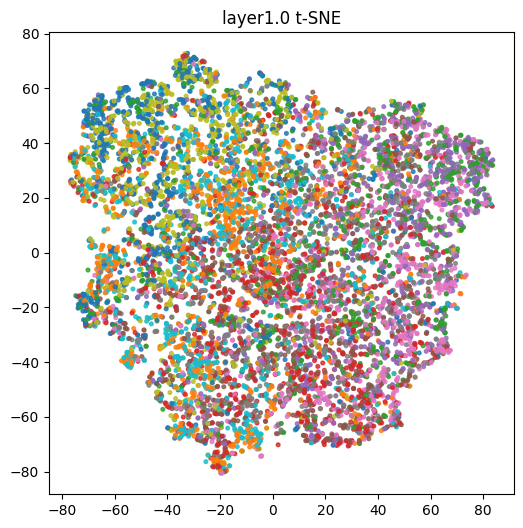

Running UMAP for layer1.0


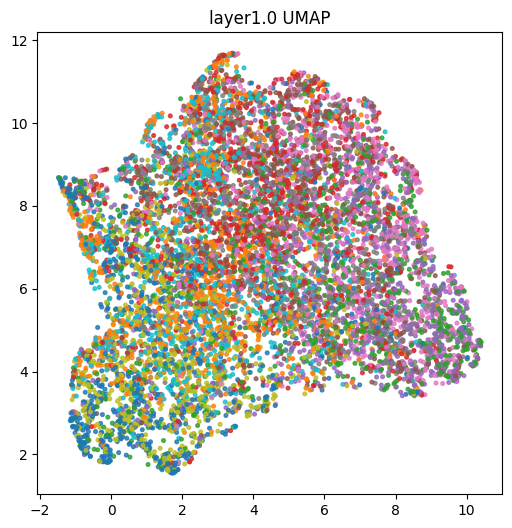

Running t-SNE for layer2.0


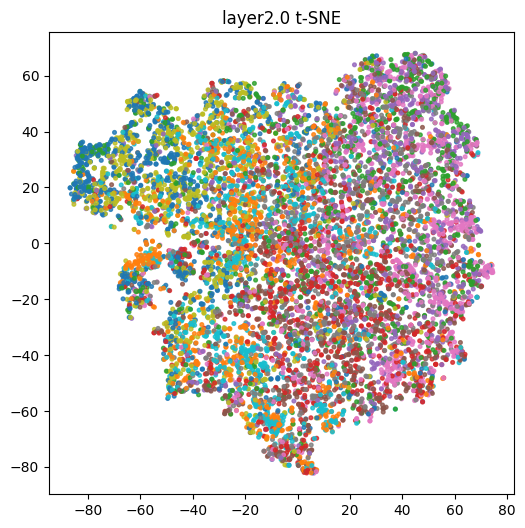

Running UMAP for layer2.0


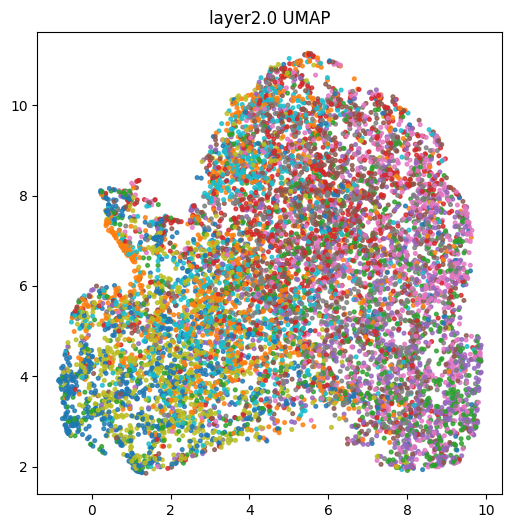

Running t-SNE for layer4.2


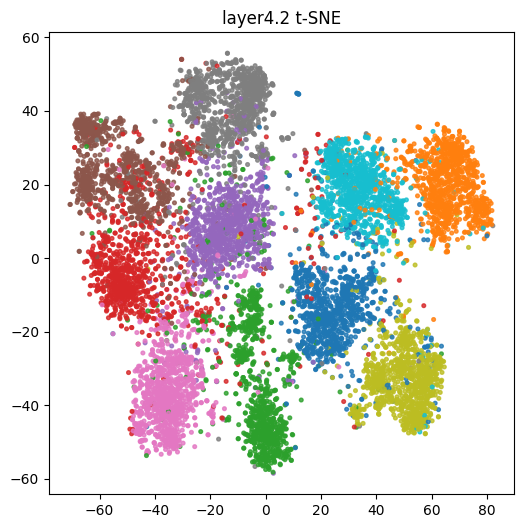

Running UMAP for layer4.2


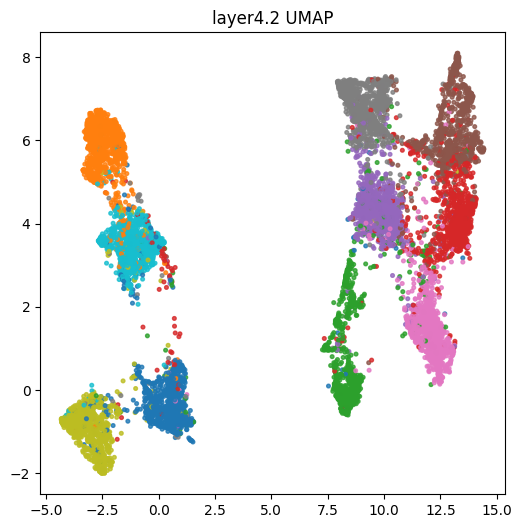

In [16]:
# visualisarion
for k in feats:
    print('Running t-SNE for', k)
    tsne_and_plot(feats[k], labels, title=f'{k} t-SNE')
    plt.show()
    print('Running UMAP for', k)
    umap_and_plot(feats[k], labels, title=f'{k} UMAP')
    plt.show()

In [ ]:
# Subtask 4: Transfer learning
def set_finetune_mode(model, mode='head'):
    if mode == 'head':
        for n,p in model.named_parameters():
            p.requires_grad = 'fc' in n
    elif mode == 'last_block':
        for n,p in model.named_parameters():
            if n.startswith('layer4') or 'fc' in n:
                p.requires_grad = True
            else:
                p.requires_grad = False
    elif mode == 'full':
        for n,p in model.named_parameters():
            p.requires_grad = True
    else:
        raise ValueError('Unknown mode')
    return model

tr_loader_100, val_loader_100 = get_dataloaders(dataset='CIFAR100')
print('CIFAR100 loaders ready')

100%|██████████| 169M/169M [00:03<00:00, 48.8MB/s]


CIFAR100 loaders ready


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# Cexperiment runner comparing pretrained vs random init, and finetune modes
def run_transfer_experiment(model_name='resnet152', pretrained=True, finetune_mode='last_block', dataset='CIFAR100', n_epochs=3):
    model = load_resnet(model_name, pretrained=pretrained, freeze_backbone=False, num_classes=100)
    model = set_finetune_mode(model, finetune_mode)
    model = model.to(device)
    params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.SGD(params, lr=0.01, momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
    scaler = GradScaler() if device.type=='cuda' else None
    criterion = nn.CrossEntropyLoss()
    history = defaultdict(list)
    tr, va = (tr_loader_100, val_loader_100)
    for e in range(1, n_epochs+1):
        print(f'Exp: {model_name} pretrained={pretrained} mode={finetune_mode} Epoch {e}/{n_epochs}')
        t_loss, t_acc = train_one_epoch(model, tr, criterion, optimizer, device, scaler)
        v_loss, v_acc = evaluate(model, va, criterion, device)
        scheduler.step()
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        print(f'Train {t_acc:.2f}% | Val {v_acc:.2f}%')
    return model, dict(history)

n_epochs = 5
# A: pretrained weights, last block finetune
mA, hA = run_transfer_experiment('resnet152', pretrained=True, finetune_mode='last_block', n_epochs=n_epochs)
# B: random init, last block finetune
mB, hB = run_transfer_experiment('resnet152', pretrained=False, finetune_mode='last_block', n_epochs=n_epochs)
# C: pretrained, full finetune
mC, hC = run_transfer_experiment('resnet152', pretrained=True, finetune_mode='full', n_epochs=n_epochs)
torch.save({'A':hA, 'B':hB, 'C':hC}, os.path.join(CHKPT_DIR, 'transfer_histories.pth'))
print('Saved transfer histories')

/tmp/ipython-input-2557249385.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if device.type=='cuda' else None


Exp: resnet152 pretrained=True mode=last_block Epoch 1/5


train:   0%|          | 0/782 [00:00<?, ?it/s]/tmp/ipython-input-3067302631.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train 33.08% | Val 61.74%
Exp: resnet152 pretrained=True mode=last_block Epoch 2/5


Train 46.12% | Val 67.45%
Exp: resnet152 pretrained=True mode=last_block Epoch 3/5


...

Train 50.04% | Val 78.56%
Exp: resnet152 pretrained=True mode=full Epoch 2/5


Train 66.43% | Val 81.75%
Exp: resnet152 pretrained=True mode=full Epoch 3/5


Train 74.41% | Val 85.77%
Exp: resnet152 pretrained=True mode=full Epoch 4/5


Train 76.62% | Val 86.27%
Exp: resnet152 pretrained=True mode=full Epoch 5/5


Train 77.45% | Val 86.44%
Saved transfer histories


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Using layer names: ['layer1.0', 'layer2.1', 'layer4.1']


ResNet-18 layer1.0 (10000, 64)


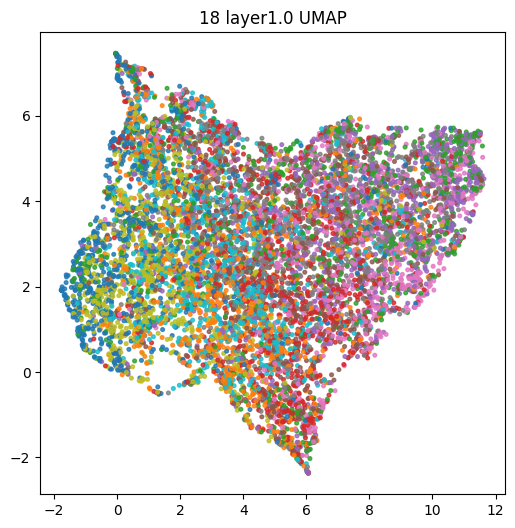

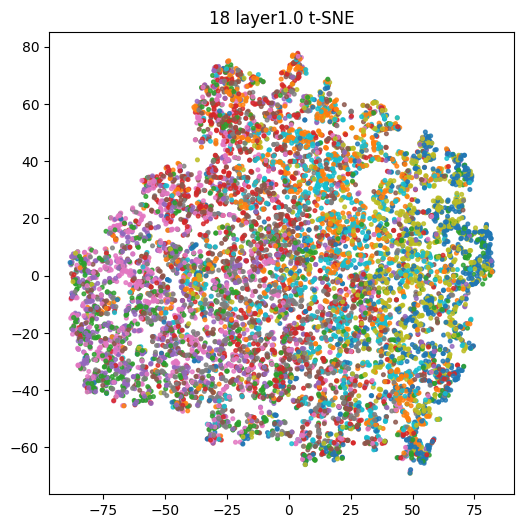

ResNet-18 layer2.1 (10000, 128)


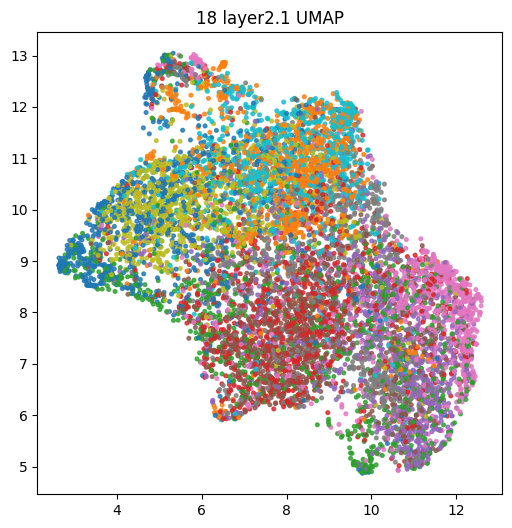

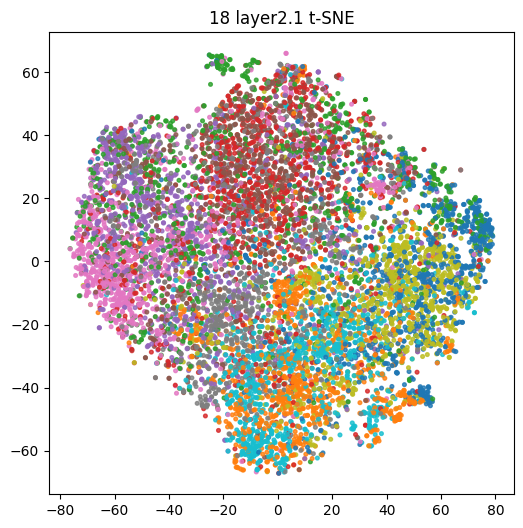

ResNet-18 layer4.1 (10000, 512)


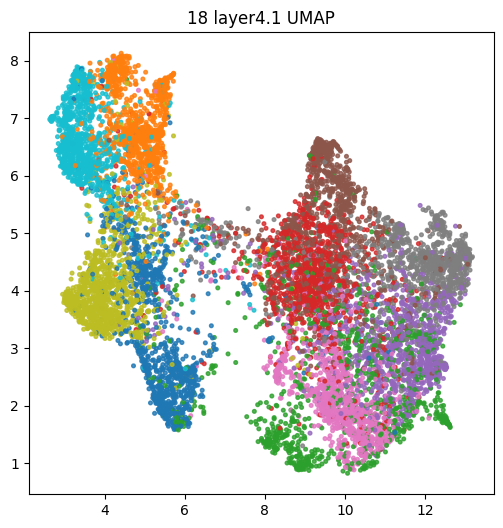

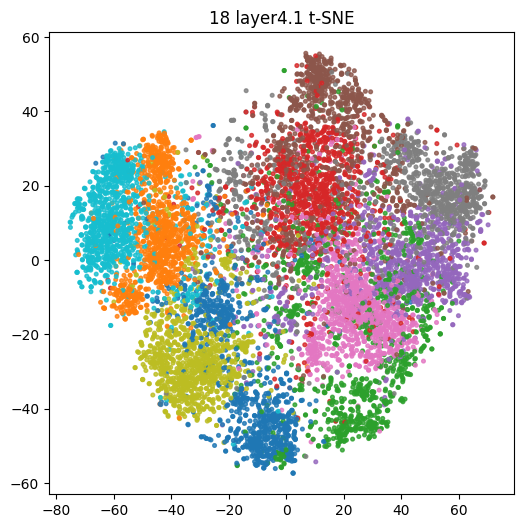

In [ ]:
# Subtask 5
def make_layer_names(model):
    def pick(layer, which):
        n = len(layer)
        if which == 'first':
            return 0
        if which == 'mid':
            return max(0, n//2)
        if which == 'last':
            return n-1
    return [f'layer1.{pick(model.layer1,"first")}',
            f'layer2.{pick(model.layer2,"mid")}',
            f'layer4.{pick(model.layer4,"last")}']

model18 = load_resnet('resnet18', pretrained=True, freeze_backbone=False)
model18.eval()
layer_names = make_layer_names(model18)
print('Using layer names:', layer_names)

extract18, rem18 = get_activation_extractor(model18, layer_names)
feats18, labels18 = extract18(val_loader)
rem18()
for k in feats18:
    print('ResNet-18', k, feats18[k].shape)
    umap_and_plot(feats18[k], labels18, title=f'18 {k} UMAP')
    plt.show()
    tsne_and_plot(feats18[k], labels18, title=f'18 {k} t-SNE')
    plt.show()

In [20]:
# ]confusion matrix
from sklearn.metrics import confusion_matrix

def collect_preds(model, loader):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc='preds', leave=False):
            imgs = imgs.to(device)
            out = model(imgs)
            _, p = out.max(1)
            preds.append(p.cpu())
            trues.append(targets)
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    return trues, preds

trues, preds = collect_preds(model, val_loader)
cm = confusion_matrix(trues, preds)

cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
inds = np.dstack(np.unravel_index(np.argsort(cm_off.ravel())[::-1], cm_off.shape))[0]  # sorted pairs
print('Top confused class pairs (true->pred) and counts:')
for (i,j) in inds[:10]:
    print(i, '->', j, cm_off[i,j])

preds:   0%|          | 0/157 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                        

Top confused class pairs (true->pred) and counts:
3 -> 5 44
5 -> 3 37
9 -> 1 20
1 -> 9 18
8 -> 0 16
4 -> 3 13
0 -> 8 13
3 -> 2 12
2 -> 6 11
6 -> 3 10


(10000, 64) (10000,)
[3 8 8 0 6 6 1 6 3 1]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


label: tensor(3)


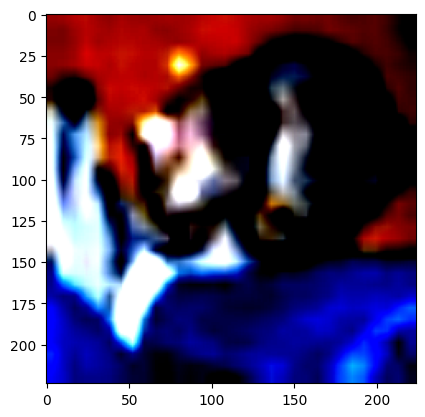

In [21]:
print(feats18['layer1.0'].shape, labels18.shape)
i = 0
print(labels18[:10])
imgs, labs = next(iter(val_loader))
plt.imshow(np.transpose(imgs[i].numpy(), (1,2,0))); print('label:', labs[i])

In [22]:
from sklearn.metrics import silhouette_score
s = silhouette_score(feats18['layer1.0'], labels18)
print('Silhouette (layer1.0) =', s)

Silhouette (layer1.0) = -0.07227917


In [23]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

def silhouette_for_feats(feats_dict, labels, pca_dim=50):
    out = {}
    for name, X in feats_dict.items():
        D = min(pca_dim, X.shape[1])
        Xp = PCA(n_components=D, random_state=42).fit_transform(X)
        s = silhouette_score(Xp, labels)
        out[name] = s
    return out

scores = silhouette_for_feats(feats18, labels18, pca_dim=50)
print(scores)

{'layer1.0': np.float32(-0.07229863), 'layer2.1': np.float32(-0.025637778), 'layer4.1': np.float32(0.039640214)}


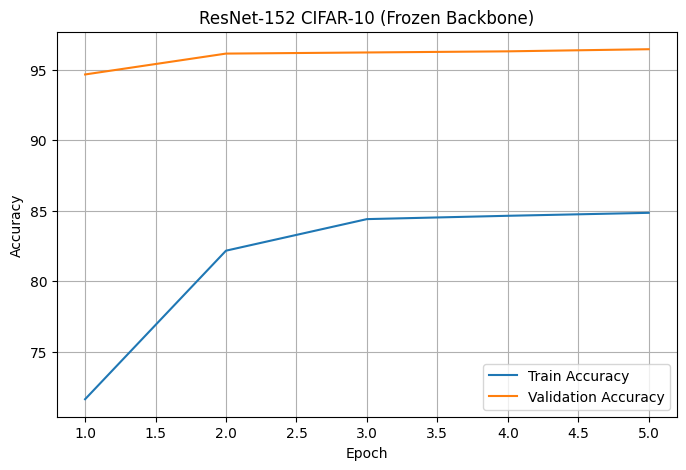

In [ ]:
# Training Curves
import matplotlib.pyplot as plt

epochs = range(1, len(history_baseline["train_acc"]) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, history_baseline["train_acc"], label="Train Accuracy")
plt.plot(epochs, history_baseline["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet-152 CIFAR-10 (Frozen Backbone)")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'history_no_residual' is not defined

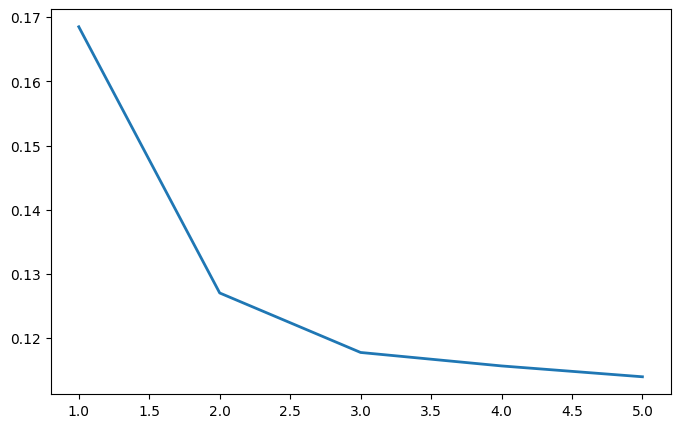

In [25]:
# Residual vs No-Residual Loss Comparison (Task 1.2)
import matplotlib.pyplot as plt

epochs = range(1, len(history_baseline["train_loss"]) + 1)

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history_baseline["val_loss"],
    label="Baseline (with residuals)",
    linewidth=2
)

plt.plot(
    epochs,
    history_no_residual["val_loss"],
    label="No residual connections",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Effect of Removing Residual Connections on Optimization")
plt.legend()
plt.grid(True)
plt.show()
